In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
class MOLR:
    def __init__(self,p,r):
        """
        p: prediction horizon
        r: memory of model (sample amount in asingle row of X)
        m: feature amount
        n: dataset length
        """
        self.p = p
        self.r = r
        self.n = None
        self.m = None
        self.W = None

    def _show(lst):
        for row in lst:
            print(row)

    def _gradient(self,Xt,Y):
        return (2 / (self.n-self.p-self.r+1)) * Xt.T @ (Xt @ self.W - Y)

    def _loss(self,Xt,Y):
        diff = Xt @ self.W - Y
        return (1 / (self.n-self.p-self.r+1)) * np.trace(diff.T @ diff)

    def _rel_cond(self,old_loss,loss,epsilon):
        return abs((loss-old_loss)/old_loss)>epsilon

    def fit(self,df,epsilon=0.01,alpha=0.01,inform=0):
        """
        epsilon: relative error threshold
        alpha: step size
        inform: 0(least informed),1,2,3(most informed)

        returns loss history
        """
        print("Model training started...")

        self.n, self.m = df.shape

        # create X
        X = np.array([df[k : k + self.r] for k in range(self.n - self.p - self.r + 1)])
        X = X.reshape(X.shape[0], -1)

        # create Y
        Y = np.array([df[k + self.r : k + self.r + self.p] for k in range(self.n - self.p - self.r + 1)])
        Y = Y.reshape(Y.shape[0], -1)

        # create Xt
        X_flattened = X.reshape(X.shape[0], -1)
        ones_column = np.ones((X_flattened.shape[0], 1))
        Xt = np.column_stack((ones_column, X_flattened))

        # create W
        self.W = np.zeros((self.r * self.m + 1, self.p * self.m))

        if inform==3:
            print("df shape:", df.shape)
            print("X shape:", X.shape)
            print("Y shape:", Y.shape)
            print("Xt shape:", Xt.shape)
            print("W shape:", self.W.shape)
            print("\n-- Weights First --")
            self._show(self.W)

        iter_num = 0
        loss = self._loss(Xt, Y)
        losses = [loss]

        while iter_num == 0 or self._rel_cond(old_loss, loss, epsilon):
            old_loss = loss
            self.W = self.W - alpha * self._gradient(Xt, Y)
            loss = self._loss(Xt, Y)

            if inform == 2:
                print(f"iter {iter_num}: loss: {loss}, old loss: {old_loss}")
            elif inform == 1:
                print(f"iter {iter_num}: loss: {loss}")

            iter_num += 1
            losses.append(loss)

        if inform == 3:
            print("\n-- Weights Last --")
            self._show(self.W)

        print("Model training finished.")
        return losses

    def predict(self, X):
        """x: 1, x1, x2, ... , xrm"""
        x = X[-self.r:].flatten()
        x = np.insert(x, 0, 1)
        preds = x @ self.W
        answers = preds.reshape(self.p, self.m)

        return answers

In [3]:
def generate_synthetic_ts(n, m):
    t = np.arange(n)
    synthetic_data = np.zeros((n, m))

    for col in range(m):
        trend_slope = np.random.uniform(-0.5, 0.5)
        seasonal_amplitude = np.random.uniform(5, 15)
        period = np.random.randint(10, 30)
        noise_level = np.random.uniform(1, 3)

        phase_shift = np.random.uniform(0, 2 * np.pi)

        trend = trend_slope * t
        seasonality = seasonal_amplitude * np.sin((2 * np.pi * t / period) + phase_shift)
        noise = np.random.normal(0, noise_level, n)

        f = trend + seasonality + noise

        synthetic_data[:, col] = f

    return synthetic_data

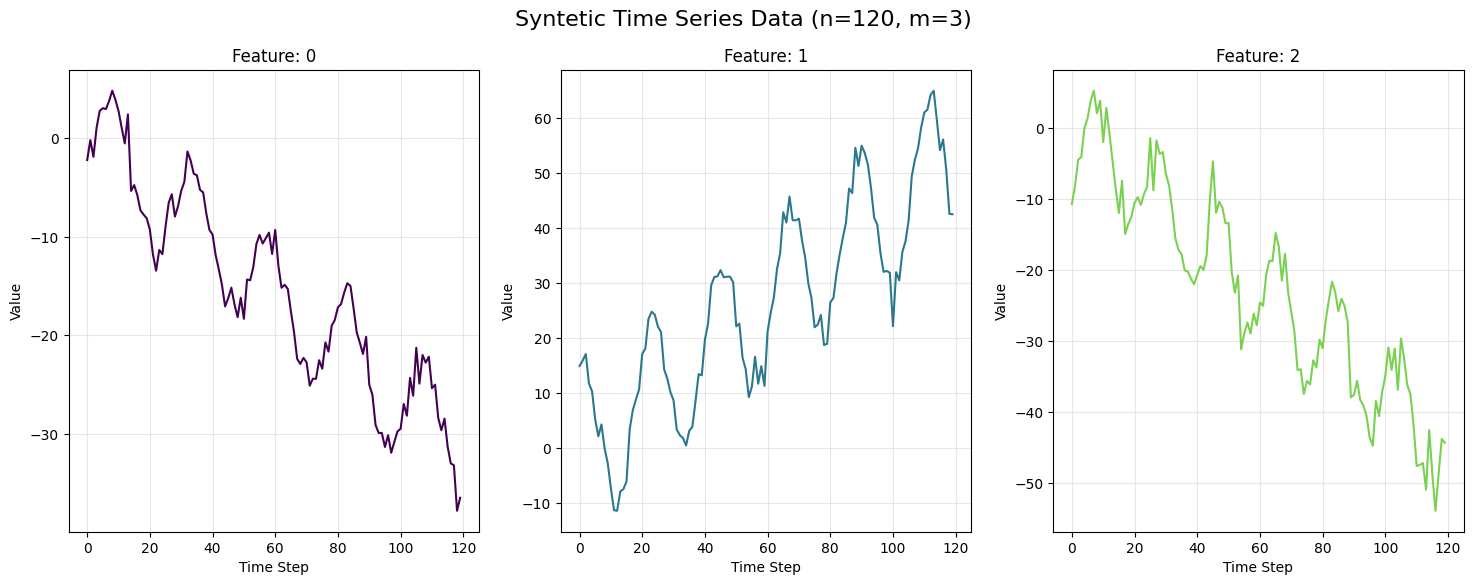

In [13]:
"""
n = 120 # dataset length
m = 3 # feature amount
p = 20 # prediction horizon
r = 20 # memory
"""
dataset_len = 120
feature_amount = 3
pred_horizon = 20
memory = 20

# create df
df = generate_synthetic_ts(n=dataset_len, m=feature_amount)

fig, axs = plt.subplots(1, 3, figsize=(6*feature_amount, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, feature_amount))
for i, (ax, color) in enumerate(zip(axs, colors)):
    ax.plot(df[:,i], c=color)
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Data (n={dataset_len}, m={feature_amount})", fontsize=16)
plt.show()

In [14]:
df[:10]

array([[ -2.19952049,  14.91175111, -10.67106025],
       [ -0.1778316 ,  15.90674489,  -8.1415907 ],
       [ -1.8783514 ,  17.09615322,  -4.42100014],
       [  1.07828595,  11.74031297,  -4.05267078],
       [  2.7956311 ,  10.30331139,   0.01963968],
       [  3.06694948,   5.1674613 ,   1.40820205],
       [  2.97784023,   2.12200713,   3.8895455 ],
       [  3.80879725,   4.27625399,   5.2920261 ],
       [  4.83855678,  -0.05868752,   2.11072301],
       [  3.93310678,  -2.78430046,   3.90416813]])

In [15]:
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df[:10]

array([[0.83498096, 0.34451495, 0.73022777],
       [0.88238271, 0.35752579, 0.77297519],
       [0.84251129, 0.37307886, 0.83585225],
       [0.9118344 , 0.30304424, 0.84207692],
       [0.95210032, 0.28425357, 0.91089797],
       [0.95846182, 0.21709561, 0.93436433],
       [0.95637251, 0.17727231, 0.97629842],
       [0.97585563, 0.2054419 , 1.        ],
       [1.        , 0.14875687, 0.94623676],
       [0.97877027, 0.11311592, 0.97654554]])

In [16]:
# build model
model = MOLR(p=20,r=20)
losses = model.fit(scaled_df,inform=2,epsilon=0.005)

Model training started...
iter 0: loss: 7.465050782519303, old loss: 16.595298290901393
iter 1: loss: 3.926574651829548, old loss: 7.465050782519303
iter 2: loss: 2.5390592058359918, old loss: 3.926574651829548
iter 3: loss: 1.979518539845798, old loss: 2.5390592058359918
iter 4: loss: 1.7392450036135843, old loss: 1.979518539845798
iter 5: loss: 1.6226120184779986, old loss: 1.7392450036135843
iter 6: loss: 1.554370056523796, old loss: 1.6226120184779986
iter 7: loss: 1.5055543340879072, old loss: 1.554370056523796
iter 8: loss: 1.46499720865555, old loss: 1.5055543340879072
iter 9: loss: 1.4283750083411524, old loss: 1.46499720865555
iter 10: loss: 1.3939966303994593, old loss: 1.4283750083411524
iter 11: loss: 1.3611842662990474, old loss: 1.3939966303994593
iter 12: loss: 1.3296507683353933, old loss: 1.3611842662990474
iter 13: loss: 1.2992602139401994, old loss: 1.3296507683353933
iter 14: loss: 1.269935806237556, old loss: 1.2992602139401994
iter 15: loss: 1.2416244250465132, ol

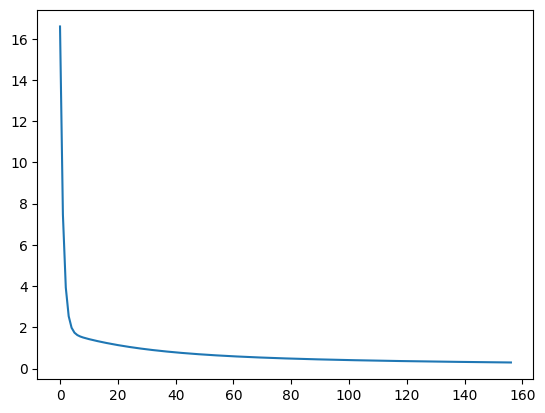

In [17]:
plt.plot(losses)

In [18]:
preds = model.predict(scaled_df)
preds_rescaled = scaler.inverse_transform(preds)
preds_rescaled

array([[-32.22770001,  44.78718493, -45.22635354],
       [-32.1043737 ,  44.10942118, -44.88446005],
       [-32.20030767,  43.64068678, -44.76105898],
       [-32.12788306,  44.10998697, -44.46071258],
       [-32.14529642,  45.06954296, -44.59529989],
       [-31.89387906,  46.5712341 , -44.18171715],
       [-31.90269507,  48.77359393, -43.70044161],
       [-31.69488409,  51.27722635, -43.89237621],
       [-31.61317863,  53.61016606, -43.90111563],
       [-31.69359146,  56.09830829, -44.27393105],
       [-32.05951048,  58.47894457, -45.0806555 ],
       [-32.39203906,  60.57346698, -45.91929893],
       [-32.96445526,  62.30002136, -46.71343449],
       [-33.4817713 ,  63.64453551, -47.82474085],
       [-33.87635764,  64.15587819, -48.34858327],
       [-34.473832  ,  63.74716987, -49.31575609],
       [-35.08812643,  63.30077173, -50.58915916],
       [-35.64600757,  62.13325848, -51.4486674 ],
       [-36.39194973,  60.37402265, -51.80165498],
       [-36.96073023,  58.66310

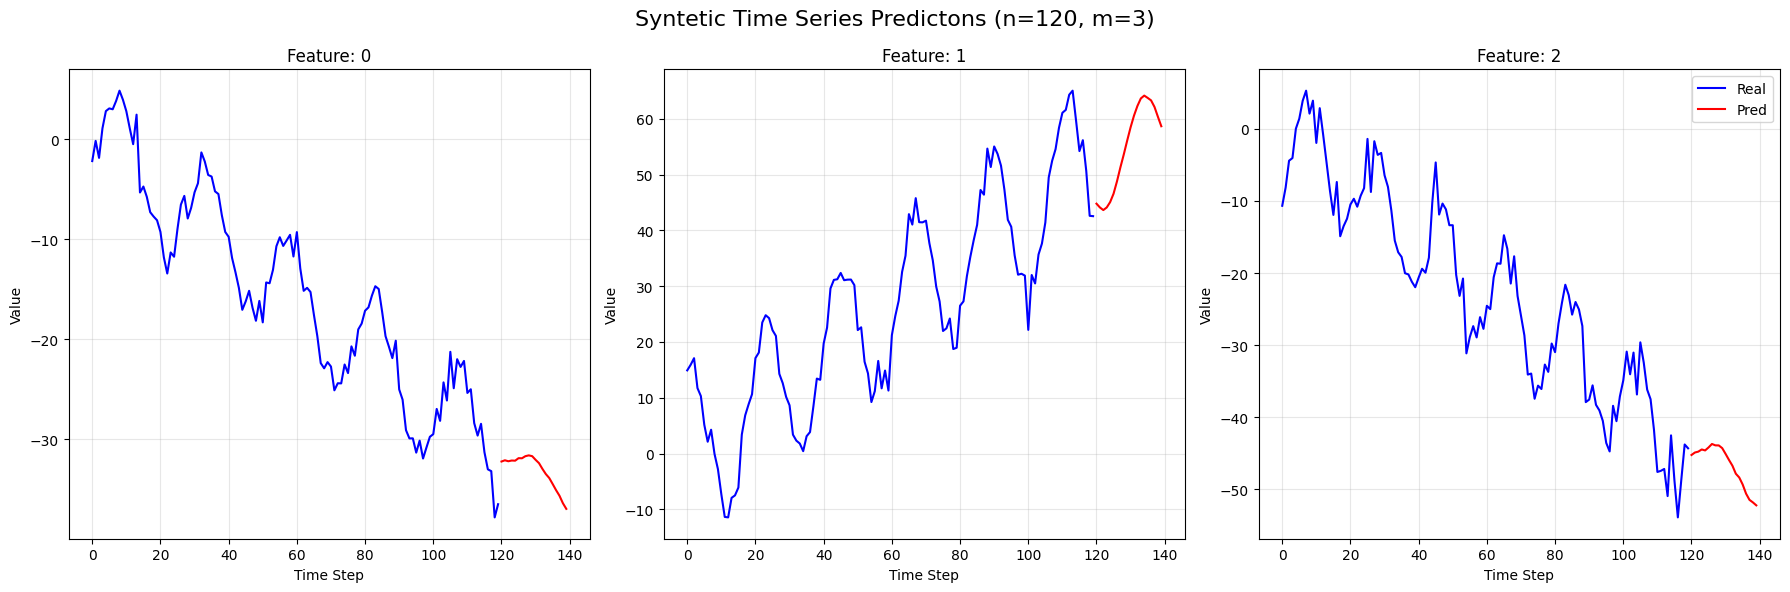

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(6*feature_amount, 6))
for i, ax in enumerate(axs):
    ax.plot(df[:,i], c="blue", label="Real")
    preds_x_axis = range(len(df), len(df) + len(preds_rescaled))
    ax.plot(preds_x_axis, preds_rescaled[:,i], c="red", label="Pred")
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Predictons (n={dataset_len}, m={feature_amount})", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()